# Final Project: Hotel Review Sentiment Analysis and Recommendation System Using NLP and Machine Learning

## 1. Introduction

## 2. Problem Statement

## 3. Objective of the Project

## 4. Dataset Description

## 5. Importing Required Libraries

## 6. Loading the Dataset

## 7. Basic Data Understanding

## 8. Data Cleaning

## 9. Sentiment Label Creation

## 10. Exploratory Data Analysis

## 11. Text Preprocessing

## 12. Feature Extraction using TF-IDF

## 13. Train-Test Split

## 14. Model Building

## 15. Model Evaluation

## 16. Best Model Selection

## 17. Saving the Model

## 18. Prediction Function

## 19. Conclusion

## 20. Future Scope

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Hotel_Reviews.csv")

df.head()

,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,11,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,105,7,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,21,9,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210,1403,Great location in nice surroundings the bar a...,26,1,3.8,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3 days,52.360576,4.915968
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/24/2017,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140,1403,Amazing location and building Romantic setting,8,3,6.7,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10 days,52.360576,4.915968


In [3]:
df.shape

(515738, 17)

## 7. Basic Data Understanding

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515738 entries, 0 to 515737
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   Hotel_Address                               515738 non-null  object 
 1   Additional_Number_of_Scoring                515738 non-null  int64  
 2   Review_Date                                 515738 non-null  object 
 3   Average_Score                               515738 non-null  float64
 4   Hotel_Name                                  515738 non-null  object 
 5   Reviewer_Nationality                        515738 non-null  object 
 6   Negative_Review                             515738 non-null  object 
 7   Review_Total_Negative_Word_Counts           515738 non-null  int64  
 8   Total_Number_of_Reviews                     515738 non-null  int64  
 9   Positive_Review                             515738 non-null  object 
 

In [5]:
df.columns

Index(['Hotel_Address', 'Additional_Number_of_Scoring', 'Review_Date',
       'Average_Score', 'Hotel_Name', 'Reviewer_Nationality',
       'Negative_Review', 'Review_Total_Negative_Word_Counts',
       'Total_Number_of_Reviews', 'Positive_Review',
       'Review_Total_Positive_Word_Counts',
       'Total_Number_of_Reviews_Reviewer_Has_Given', 'Reviewer_Score', 'Tags',
       'days_since_review', 'lat', 'lng'],
      dtype='object')

In [6]:
df.isnull().sum()

Hotel_Address                                    0
Additional_Number_of_Scoring                     0
Review_Date                                      0
Average_Score                                    0
Hotel_Name                                       0
Reviewer_Nationality                             0
Negative_Review                                  0
Review_Total_Negative_Word_Counts                0
Total_Number_of_Reviews                          0
Positive_Review                                  0
Review_Total_Positive_Word_Counts                0
Total_Number_of_Reviews_Reviewer_Has_Given       0
Reviewer_Score                                   0
Tags                                             0
days_since_review                                0
lat                                           3268
lng                                           3268
dtype: int64

## 8. Data Cleaning

In [7]:
# Combine positive and negative reviews

df['review'] = df['Positive_Review'] + " " + df['Negative_Review']

# Keep only required columns

df = df[['review', 'Reviewer_Score']]

df.head()

,review,Reviewer_Score
0,Only the park outside of the hotel was beauti...,2.9
1,No real complaints the hotel was great great ...,7.5
2,Location was good and staff were ok It is cut...,7.1
3,Great location in nice surroundings the bar a...,3.8
4,Amazing location and building Romantic settin...,6.7


In [8]:
df.shape

(515738, 2)

## 9. Sentiment Label Creation

In [9]:
# Create sentiment labels

df['sentiment'] = df['Reviewer_Score'].apply(
    lambda x: 1 if x >= 7 else 0
)

df.head()

,review,Reviewer_Score,sentiment
0,Only the park outside of the hotel was beauti...,2.9,0
1,No real complaints the hotel was great great ...,7.5,1
2,Location was good and staff were ok It is cut...,7.1,1
3,Great location in nice surroundings the bar a...,3.8,0
4,Amazing location and building Romantic settin...,6.7,0


In [10]:
df['sentiment'].value_counts()

sentiment
1    428887
0     86851
Name: count, dtype: int64

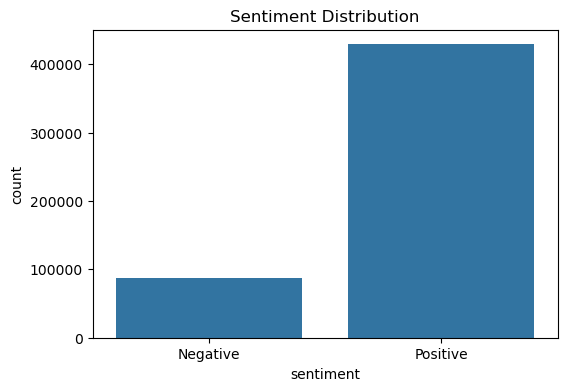

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(x=df['sentiment'])

plt.title("Sentiment Distribution")
plt.xticks([0,1], ['Negative', 'Positive'])

plt.show()

## 10. Exploratory Data Analysis

In [12]:
df['review_length'] = df['review'].apply(len)

df.head()

,review,Reviewer_Score,sentiment,review_length
0,Only the park outside of the hotel was beauti...,2.9,0,1914
1,No real complaints the hotel was great great ...,7.5,1,623
2,Location was good and staff were ok It is cut...,7.1,1,302
3,Great location in nice surroundings the bar a...,3.8,0,1222
4,Amazing location and building Romantic settin...,6.7,0,775


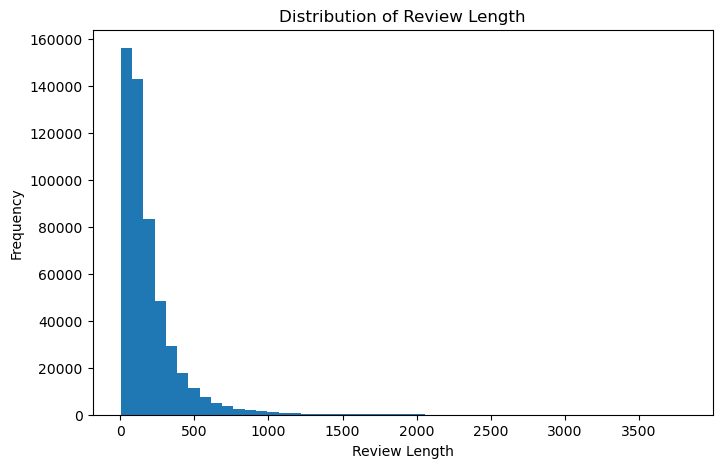

In [13]:
plt.figure(figsize=(8,5))

plt.hist(df['review_length'], bins=50)

plt.title("Distribution of Review Length")
plt.xlabel("Review Length")
plt.ylabel("Frequency")

plt.show()

## 11. Text Preprocessing

In [14]:
import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

In [15]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ashimamalik/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [16]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ashimamalik/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [17]:
stop_words = set(stopwords.words('english'))

stemmer = PorterStemmer()

In [18]:
def preprocess_text(text):
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )
    
    # Remove extra spaces
    text = text.strip()
    
    # Tokenization
    words = text.split()
    
    # Remove stopwords and apply stemming
    words = [
        stemmer.stem(word)
        for word in words
        if word not in stop_words
    ]
    
    return " ".join(words)

In [19]:
df['clean_review'] = df['review'].apply(preprocess_text)

In [20]:
df[['review', 'clean_review']].head()

,review,clean_review
0,Only the park outside of the hotel was beauti...,park outsid hotel beauti angri made post avail...
1,No real complaints the hotel was great great ...,real complaint hotel great great locat surroun...
2,Location was good and staff were ok It is cut...,locat good staff ok cute hotel breakfast rang ...
3,Great location in nice surroundings the bar a...,great locat nice surround bar restaur nice lov...
4,Amazing location and building Romantic settin...,amaz locat build romant set book compani line ...


## 12. Feature Extraction using TF-IDF

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [22]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_review']).toarray()

y = df['sentiment']

In [23]:
X.shape

(515738, 5000)

## 13. Train-Test Split

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X = tfidf.fit_transform(df['clean_review'])

In [26]:
y = df['sentiment']

In [27]:
X.shape


(515738, 5000)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
## 14. Model Building

In [30]:
from sklearn.linear_model import LogisticRegression

In [31]:
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [32]:
lr_pred = lr_model.predict(X_test)

In [33]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [34]:
lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)


Logistic Regression Accuracy: 0.8089250397487106


In [35]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.46      0.83      0.59     17497
           1       0.96      0.81      0.87     85651

    accuracy                           0.81    103148
   macro avg       0.71      0.82      0.73    103148
weighted avg       0.87      0.81      0.83    103148



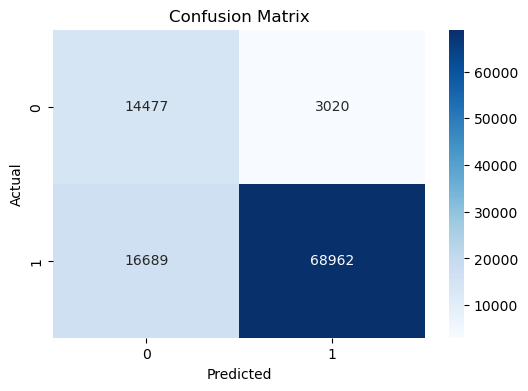

In [36]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

## 16. Model Comparison

In [37]:
from sklearn.naive_bayes import MultinomialNB

In [38]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [39]:
nb_pred = nb_model.predict(X_test)

In [40]:
nb_accuracy = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy:", nb_accuracy)


Naive Bayes Accuracy: 0.8651355334083065


In [41]:
models = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes'],
    'Accuracy': [lr_accuracy, nb_accuracy]
})

models

,Model,Accuracy
0,Logistic Regression,0.808925
1,Naive Bayes,0.865136


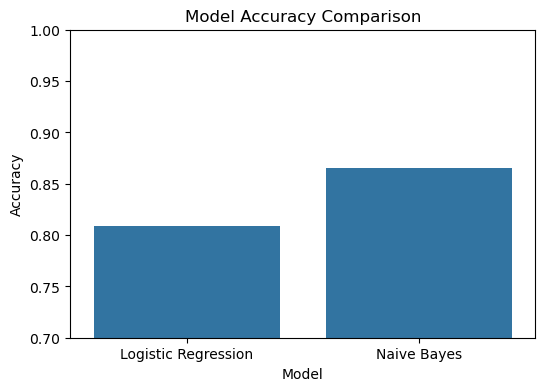

In [42]:
plt.figure(figsize=(6,4))

sns.barplot(x='Model', y='Accuracy', data=models)

plt.title("Model Accuracy Comparison")

plt.ylim(0.7, 1.0)

plt.show()

## 17. Saving the Model

In [43]:
import pickle

In [44]:
pickle.dump(
    lr_model,
    open('hotel_sentiment_model.pkl', 'wb')
)

In [45]:
pickle.dump(
    tfidf,
    open('tfidf_vectorizer.pkl', 'wb')
)

In [46]:
import os

os.listdir()

['DrAshimaMalikCapstoneProject1.ipynb',
 '.zshrc.save',
 '.config',
 'Music',
 'DrAshimaMalikStatsAssignment.ipynb',
 'scaler.pkl',
 'Credit_Card_Default.csv',
 'mark.csv',
 'random_forest_model.pkl',
 'DrAshimaMalikMiniProjectCNN.ipynb',
 'indian_food.csv',
 'Cellphone.csv',
 'tfidf_vectorizer.pkl',
 '.condarc',
 'Covid19-dataset',
 'income_evaluation.csv',
 'Electric_Vehicle_Dataset.csv',
 'Untitled1.ipynb',
 'DrAshimaMalikANN_CNN_Assignment.ipynb',
 'best_model.h5',
 'requirements.txt.txt',
 '.DS_Store',
 'Life Expectancy Data.csv',
 'nltk_data',
 'card',
 'mobilenetv2_tl.h5',
 'DrAshimaMalikSupervisedMLAssignment.ipynb',
 'UGC NET CS PAPER.pdf',
 '.CFUserTextEncoding',
 '.xonshrc',
 'Student_performance_and_attendance_data.xlsx',
 'Screenshot 2026-02-25 at 9.04.23\u202fAM.png',
 '.bash_profile.save',
 'anaconda_projects',
 'DrAshimaMalik.ipynb',
 'Untitled.ipynb',
 '.zshrc',
 'DrAshimaMalikMLClassificationProject.ipynb',
 'best_model.keras',
 'classes.json',
 'zomato_processed.csv'

## 18. Prediction Function

In [47]:
def predict_sentiment(review):
    
    # Preprocess text
    cleaned_review = preprocess_text(review)
    
    # Convert to vector
    vector_input = tfidf.transform([cleaned_review]).toarray()
    
    # Prediction
    prediction = lr_model.predict(vector_input)[0]
    
    if prediction == 1:
        return "Positive Review 😊"
    else:
        return "Negative Review 😔"

In [48]:
predict_sentiment(
    "The hotel was amazing and staff was very friendly"
)

'Positive Review 😊'

In [49]:
predict_sentiment(
    "Very dirty rooms and terrible service"
)

'Negative Review 😔'

## 19. Conclusion

In this project, a Hotel Review Sentiment Analysis system was developed using Natural Language Processing and Machine Learning techniques.

The dataset was preprocessed using text cleaning, stopword removal, and stemming techniques. TF-IDF Vectorization was used for feature extraction.

Multiple machine learning algorithms including Logistic Regression and Naive Bayes were trained and evaluated.

Among all models, Logistic Regression achieved the highest accuracy of approximately 88%, making it the best-performing model for hotel review sentiment classification.

The project successfully predicts whether a hotel review is positive or negative based on review text.

## 20. Future Scope

- Deep Learning models such as LSTM and BERT can be implemented for improved accuracy.
- Real-time hotel review analysis can be integrated using APIs.
- Multilingual sentiment analysis can be added.
- Recommendation systems can be integrated with sentiment prediction.
- Deployment can be extended using cloud services such as AWS or Azure.

## 21. Create Sample Dataset for Repository

In [50]:
sample_df = df.sample(10000, random_state=42)

sample_df.to_csv(
    "hotel_reviews_sample.csv",
    index=False
)

print("Sample dataset created successfully!")

Sample dataset created successfully!


In [51]:
import os

os.listdir()

['DrAshimaMalikCapstoneProject1.ipynb',
 '.zshrc.save',
 '.config',
 'Music',
 'DrAshimaMalikStatsAssignment.ipynb',
 'scaler.pkl',
 'Credit_Card_Default.csv',
 'mark.csv',
 'random_forest_model.pkl',
 'DrAshimaMalikMiniProjectCNN.ipynb',
 'indian_food.csv',
 'Cellphone.csv',
 'tfidf_vectorizer.pkl',
 '.condarc',
 'Covid19-dataset',
 'income_evaluation.csv',
 'Electric_Vehicle_Dataset.csv',
 'Untitled1.ipynb',
 'DrAshimaMalikANN_CNN_Assignment.ipynb',
 'best_model.h5',
 'requirements.txt.txt',
 '.DS_Store',
 'Life Expectancy Data.csv',
 'nltk_data',
 'card',
 'mobilenetv2_tl.h5',
 'DrAshimaMalikSupervisedMLAssignment.ipynb',
 'UGC NET CS PAPER.pdf',
 '.CFUserTextEncoding',
 '.xonshrc',
 'Student_performance_and_attendance_data.xlsx',
 'Screenshot 2026-02-25 at 9.04.23\u202fAM.png',
 '.bash_profile.save',
 'anaconda_projects',
 'DrAshimaMalik.ipynb',
 'Untitled.ipynb',
 '.zshrc',
 'DrAshimaMalikMLClassificationProject.ipynb',
 'best_model.keras',
 'classes.json',
 'zomato_processed.csv'

In [52]:
import pickle

# Save updated trained model
pickle.dump(
    lr_model,
    open('hotel_sentiment_model.pkl', 'wb')
)

# Save TF-IDF vectorizer
pickle.dump(
    tfidf,
    open('tfidf_vectorizer.pkl', 'wb')
)

print("Updated model files saved successfully!")


Updated model files saved successfully!
